# 혼합 디코더(손=분류, 팔=Cartesian 상대 회귀+역기구학)로 SO-101 팔 + AmazingHand 손 구동

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, 다른 노트북들과
같은 `examples` 의존성 그룹만 사용합니다).

**목표**: `04`번은 손+팔 모두 분류(이산 행동)로, `05`번은 손+팔 모두 회귀(절대 관절각)로 구동했습니다.
이 노트북은 **분류 모델 1개 + 회귀 모델 1개, 총 2개의 독립적인 모델을 한 디코더 안에서 섞습니다** —
손은 분류(`"grip"`/`"release"`), 팔은 회귀로 예측한 **Cartesian 상대 이동량**(`dx`, `dy`, 예:
"+0.5cm")을 현재 위치에 더한 뒤 역기구학(inverse kinematics, IK)으로 풀어서 구동합니다.

역할 분리는 이전 노트북들과 동일하되, 이번엔 디코더 안에 서로 완전히 독립된 두 모델(공유 trunk
없음, 각자 다른 optimizer/loss)이 들어갑니다:

1. **`Decoder`** (`MixedDecoder`) — `HandGestureClassifier`(분류)와 `ArmOffsetRegressor`(회귀) 두
   독립 모델을 감싸서, 순수하게 `{"hand_class": 0 | 1, "dx": meters, "dy": meters}`를 예측만
   합니다. `config.type`을 `(DecoderType.CLASSIFICATION, DecoderType.REGRESSION)` 튜플로
   표시합니다. `dx`/`dy`는 현재 위치를 기준으로 한 **상대** 이동량이지, 미리 정해둔 절대 좌표가
   아닙니다.
2. **`MixedCommand`** — `hand_class`를 `"grip"`/`"release"` 이름으로 바꾸고(이미 자기 설명적인
   이름이 되므로 그대로 전달), `dx`/`dy`는 raw 회귀 값이므로 `(ActionType.CARTESIAN_RELATIVE,
   {"dx": ..., "dy": ...})` 튜플로 태그합니다.
3. **`n2o.robot.Part` (`AmazingHand`) + `Robot.router()`, 그리고 `SO101IKSolver`** — 손 쪽은
   `04`번과 동일한 이산 조회 테이블(`AmazingHand.GESTURES`)이고, `Robot.router()`가
   `ControllerType.SIMULATION`일 때 `goal()`(순수 계산, 하드웨어 접근 없음)을 불러 그 결과를
   `Simulator.drive("hand", ...)`로 넘깁니다. 팔 쪽은 사정이 다릅니다 — `SO101Arm`은
   `"up"`/`"down"` 두 이산 제스처만 지원하고 이 노트북이 필요로 하는 Cartesian(`dx`, `dy`) 상대
   오프셋은 아직 지원하지 않으므로(`ROADMAP.md`), `Robot.router()`를 거치지 않고
   `n2o.robot.arm.lerobot_robot_so101_5dof.solver.SO101IKSolver`를 직접 호출해 감쇠
   최소제곱(damped least squares) IK로 `shoulder_pan`/`shoulder_lift`/`elbow_flex` 관절 각도를
   풀어냅니다. `SO101IKSolver.solve()`는 매 반복마다 결과를 공식 가동범위로 clamp합니다 — 벤더가
   제공하는 안전장치가 없다는 사실을 이 프로젝트에서 반복해서 확인했으므로, IK 자체가 그
   안전장치 역할을 겸합니다. `solve()`는 순수 함수라 "지금 팔이 어디 있는지" 스스로 기억하지
   않으므로, 이 노트북이 그 상태(`current_arm_deg`)를 평범한 파이썬 변수로 직접 추적합니다.

로봇 모델은 이전 노트북들과 동일하게 공식 CAD 출처를 그대로 사용합니다 (`assets/so101/`,
`assets/amazing_hand_right/`). 이 노트북도 **시뮬레이션만** 다루며, 실제 하드웨어에는 어떤 명령도
보내지 않습니다.

In [ ]:
import os

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch

from n2o import N2O
from n2o.command import ActionType, Command, CommandConfig
from n2o.decoder import Decoder, DecoderConfig, DecoderType, FeatureType
from n2o.robot.arm.lerobot_robot_so101_5dof.solver import (
    ARM_JOINTS,
    SO101IKSolver,
    real_deg_to_mj_rad,
)
from n2o.robot.arm.so101 import GESTURES as ARM_GESTURES
from n2o.robot.hand.amazing_hand import AmazingHand
from n2o.robot.simulation import Simulator

HAND_LABELS = ["grip", "release"]

## 1. 합성 신호 생성

`03`/`05`번과 같은 이유로 합성 신호를 사용합니다. 이번엔 신호 하나가 **이산 라벨**(`hand_label`)과
**연속 상대 이동량**(`dx`, `dy`)을 동시에 결정합니다. `dx`/`dy`는 한 번의 명령으로 움직일 수 있는
작은 상대 걸음(최대 ±2cm)이고, 팔 컨트롤러가 매번 현재 위치에 이 값을 더해서 다음 목표를 정합니다.
목표가 미리 IK로 도달 가능성을 확인해둔 사각형(`x ∈ [0.26, 0.34]`, `y ∈ [-0.10, 0.10]`, 고정 높이
`z = 0.15`)을 벗어나지 않도록, 팔 컨트롤러가 매번 그 범위로 clamp합니다.

In [2]:
RNG = np.random.default_rng(0)  # 재현성

N_CHANS = 8
N_TIMES = 250  # 1s @ 250Hz 가정

# 미리 IK로 도달 가능성을 확인해둔 사각형 (아래 3절의 SO101ArmController가 매번 이 범위로 clamp)
ARM_X_RANGE = (0.26, 0.34)
ARM_Y_RANGE = (-0.10, 0.10)
ARM_Z = 0.15
ARM_OFFSET_RANGE = 0.02  # 한 번의 명령으로 움직일 수 있는 최대 상대 이동량 (±2cm)


def make_synthetic_sample():
    """손 라벨(grip/release)과 팔의 상대 이동량 (dx, dy)에 상관된 합성 신호 한 개를 만듭니다.

    실제 프로젝트에서는 이 함수 대신 `n2o.signal.dataset.DatasetLoader`의 실제 구현의
    `read()`가 이 자리를 대체합니다.
    """
    hand_idx = RNG.integers(0, 2)
    dx = RNG.uniform(-ARM_OFFSET_RANGE, ARM_OFFSET_RANGE)
    dy = RNG.uniform(-ARM_OFFSET_RANGE, ARM_OFFSET_RANGE)

    dx_norm = (dx + ARM_OFFSET_RANGE) / (2 * ARM_OFFSET_RANGE)
    dy_norm = (dy + ARM_OFFSET_RANGE) / (2 * ARM_OFFSET_RANGE)
    freq = 5 + 3 * hand_idx  # hand_label -> 주파수
    amplitude = 0.5 + 1.0 * dx_norm  # dx -> 진폭
    phase = dy_norm * np.pi  # dy -> 위상

    t = np.linspace(0, 1, N_TIMES, endpoint=False)
    signal = np.stack(
        [
            amplitude * np.sin(2 * np.pi * freq * t + phase)
            + RNG.normal(0, 0.3, N_TIMES)
            for _ in range(N_CHANS)
        ]
    )
    return signal.astype(np.float32), hand_idx, np.array([dx, dy], dtype=np.float32)


X0, hand0, offset0 = make_synthetic_sample()
print("합성 신호 shape (n_chans, n_times):", X0.shape)
print("hand_label:", HAND_LABELS[hand0], " arm offset (dx, dy):", offset0.round(4))

합성 신호 shape (n_chans, n_times): (8, 250)
hand_label: release  arm offset (dx, dy): [-0.0092 -0.0184]


## 2. 학습/검증용 합성 데이터셋 만들기

In [3]:
N_SAMPLES = 200
X_all = np.zeros((N_SAMPLES, N_CHANS, N_TIMES), dtype=np.float32)
hand_all = np.zeros(N_SAMPLES, dtype=np.int64)
offset_all = np.zeros((N_SAMPLES, 2), dtype=np.float32)
for i in range(N_SAMPLES):
    X_all[i], hand_all[i], offset_all[i] = make_synthetic_sample()

n_train = 160
X_train, hand_train, offset_train = (
    X_all[:n_train],
    hand_all[:n_train],
    offset_all[:n_train],
)
X_valid, hand_valid, offset_valid = (
    X_all[n_train:],
    hand_all[n_train:],
    offset_all[n_train:],
)
print(f"train samples: {len(X_train)}, valid samples: {len(X_valid)}")

train samples: 160, valid samples: 40


## 3. `SO101IKSolver` + 상태 추적, `AmazingHand`: 공식 CAD 시뮬레이션

손 쪽은 `n2o.robot.hand.AmazingHand`(`04`번과 동일한 이산 조회 테이블, `GESTURES`)와
`Robot.router()`가 그대로 처리합니다 — `n2o.robot.controller`가 `ControllerType.SIMULATION`이면
`router()`가 `AmazingHand.goal()`(순수 계산)을 부르고, 그 결과를 `Simulator.drive("hand", ...)`로
넘겨 시각화합니다. 실제 서보에는 어떤 명령도 가지 않습니다(`move()`는 아예 호출되지 않습니다).

팔 쪽이 이번 노트북의 핵심입니다 — `SO101Arm`은 `"up"`/`"down"` 두 이산 제스처만 알고 있어서
`Command`가 만드는 `(ActionType.CARTESIAN_RELATIVE, {"dx": ..., "dy": ...})` 형태를 직접 받을 수
없습니다(`ROADMAP.md` 참고). 그래서 `Robot.router()`를 거치지 않고, 순수 IK 계산만 담당하는
`n2o.robot.arm.lerobot_robot_so101_5dof.solver.SO101IKSolver`를 이 노트북이 직접 호출합니다.
`SO101IKSolver.solve(current_deg, dx, dy)`는 현재 관절각(`current_deg`)에 상대 이동량을 더한
목표점을 감쇠 최소제곱(damped least squares) IK로 `shoulder_pan`/`shoulder_lift`/`elbow_flex`
관절 각도로 풀어내고, 매 반복마다 공식 가동범위로 clamp합니다. `solve()`는 순수 함수라 "지금 팔이
어디 있는지" 스스로 기억하지 않으므로, 그 상태를 이 노트북이 평범한 파이썬 변수(`current_arm_deg`)로
직접 추적하며 매 스텝 갱신합니다 — 이전에는 `self.arm_sim.data.site_xpos`로 살아있는 시뮬레이션
상태를 직접 읽었지만, `Simulator`는 그런 내부 상태를 공개 API로 노출하지 않습니다.

In [ ]:
ik_solver = SO101IKSolver(x_range=ARM_X_RANGE, y_range=ARM_Y_RANGE, z=ARM_Z)

# 시작 자세는 "up" 제스처의 관절각을 그대로 씁니다 (임의 선택 -- "down"이어도 무방합니다).
current_arm_deg = dict(ARM_GESTURES["up"])

simulator = Simulator()  # 손/팔 시뮬레이션을 함께 구동할 하나의 Simulator 인스턴스


def apply_arm_offset(dx, dy):
    """(dx, dy) Cartesian 상대 이동량을 현재 팔 상태에 IK로 적용하고, 시뮬레이터로 구동합니다.

    `SO101Arm.move()`/`goal()`은 Cartesian 오프셋을 모르므로 `Robot.router()`를 거치지 않고
    `SO101IKSolver.solve()`를 직접 호출합니다. `current_arm_deg`(팔의 "현재 위치")를 이 함수가
    직접 갱신합니다 -- `solve()` 자신은 순수 함수라 상태를 기억하지 않으므로, 이 변수가 "현재
    위치"의 단일 진실 공급원(source of truth) 역할을 합니다.
    """
    global current_arm_deg
    target_deg, ik_error = ik_solver.solve(current_arm_deg, dx, dy)
    current_arm_deg = target_deg
    simulator.drive("arm", target_deg)
    return target_deg, ik_error

## 4. `Decoder` 서브클래스: 완전히 독립된 분류 모델 + 회귀 모델

`N2O`는 디코더 슬롯이 하나뿐이므로, 손(분류)과 팔(회귀)을 함께 예측하려면 한 `Decoder` 안에 두
모델을 둬야 합니다 — 하지만 trunk를 공유하지 않는 **완전히 독립적인** 두 모델(`HandGestureClassifier`,
`ArmOffsetRegressor`)입니다. 각자 자기 optimizer/loss로 따로 학습되므로, 손 예측이 팔 학습에,
팔 예측이 손 학습에 전혀 영향을 주지 않습니다. `decode()`는 여전히 순수 예측만 반환할 뿐, 그 값을
팔/손이 어떻게 쓸지는 전혀 모릅니다. `config.type`을 `(DecoderType.CLASSIFICATION,
DecoderType.REGRESSION)` 튜플로 표시해서 두 하위 모델이 섞여 있음을 나타냅니다.

`n2o.decoder.Classification`/`Regression`이 아니라 `Decoder`를 직접 상속합니다 — 이 디코더는
분류/회귀 어느 한쪽 태스크가 아니라 둘 다이고, 트라이얼당 이벤트 윈도우 하나(`Classification`)도
전체 레코딩에 슬라이딩 윈도우(`Regression`)도 아닌 제3의 형태가 필요할 수 있기 때문입니다. `Decoder`는
`preprocess()`/`window()`를 공통 기본 구현 없는 abstractmethod로 선언해두므로, 이 노트북은 합성
신호만 쓰고(`prepare()`를 부르지 않음) 실제 windowing 로직이 필요 없어서 둘 다 스텁으로 남겨둡니다.

In [ ]:
class HandGestureClassifier(torch.nn.Module):
    """손 제스처만 예측하는 독립 분류 모델."""

    def __init__(self, n_chans, n_times, n_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(16, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class ArmOffsetRegressor(torch.nn.Module):
    """팔의 상대 이동량 (dx, dy)만 예측하는 독립 회귀 모델."""

    def __init__(self, n_chans, n_times):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(16, 2),  # dx, dy
        )

    def forward(self, x):
        return self.net(x)


class MixedDecoder(Decoder):
    """손 제스처(분류)와 팔의 상대 이동량(회귀)을 각각 독립적인 모델로 예측하는 디코더.

    두 모델은 trunk를 공유하지 않습니다 — 하나의 모델을 두 목적에 억지로 재학습시키는 게 아니라,
    처음부터 완전히 분리된 두 모델을 한 디코더가 감쌀 뿐입니다.
    """

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {"hand_class": "0 | 1", "dx": "meters", "dy": "meters"}
        self.config = DecoderConfig(
            type=(DecoderType.CLASSIFICATION, DecoderType.REGRESSION)
        )
        self.classifier = HandGestureClassifier(
            n_chans, n_times, n_classes=len(HAND_LABELS)
        )
        self.regressor = ArmOffsetRegressor(n_chans, n_times)

    def preprocess(self, raw_dataset, **kwargs):
        # 이 노트북은 합성 신호만 쓰고 prepare()를 부르지 않으므로 구현이 필요 없습니다 --
        # 분류/회귀 어느 한쪽 레시피(bandpass_standardize() 자체는 같지만, 그걸 어떤 식으로
        # 조합할지)도 아직 정해지지 않아 스텁으로 남겨둡니다.
        raise NotImplementedError

    def window(self, raw_dataset, **kwargs):
        # 트라이얼당 이벤트 윈도우 하나(Classification)도 슬라이딩 윈도우(Regression)도 아닌
        # 제3의 형태(예: 손 라벨은 이벤트 기준, 팔 오프셋은 슬라이딩)가 필요할 수 있어 아직
        # 정해지지 않았습니다.
        raise NotImplementedError

    def decode(self, signal):
        self.classifier.eval()
        self.regressor.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float()
            class_logits = self.classifier(x)
            offset = self.regressor(x)[0]
        hand_class = int(class_logits.argmax(dim=1).item())
        return {
            "hand_class": hand_class,
            "dx": float(offset[0]),
            "dy": float(offset[1]),
        }


decoder = MixedDecoder(n_chans=N_CHANS, n_times=N_TIMES)
print(decoder.classifier)
print(decoder.regressor)

## 5. `MixedCommand`: 자기 설명적 이름은 그대로, raw 값은 태그해서 전달

`decoded_signal["hand_class"]`는 정수 인덱스라 그 자체로는 의미가 없으므로 `"grip"`/`"release"`
이름으로 바꾼 뒤에는 이미 자기 설명적이라 그대로 전달합니다. 반면 `dx`/`dy`는 raw 회귀 값이라
`(ActionType.CARTESIAN_RELATIVE, {"dx": ..., "dy": ...})` 튜플로 태그해서, 팔의 `Controller`가
"이 값은 상대 이동량이다"라는 것을 알 수 있게 합니다.

In [7]:
HAND_CLASS_TO_LABEL = {0: "grip", 1: "release"}


class MixedCommand(Command):
    """분류 결과는 이름으로, 회귀 결과는 `ActionType.CARTESIAN_RELATIVE`로 태그해서 나눠 보냅니다."""

    def translate(self, decoder, decoded_signal):
        return {
            "type": decoder.config.type,
            "arm": (
                ActionType.CARTESIAN_RELATIVE,
                {"dx": decoded_signal["dx"], "dy": decoded_signal["dy"]},
            ),
            "hand": HAND_CLASS_TO_LABEL[decoded_signal["hand_class"]],
        }


command = MixedCommand()

## 6. 학습 sanity check (두 모델을 각자 따로 학습)

`decoder.classifier`는 `CrossEntropyLoss` + 자기 optimizer로, `decoder.regressor`는 `MSELoss` +
또 다른 optimizer로 완전히 따로 학습시킵니다 — 두 loss를 더해서 하나의 모델을 학습시키던 이전
방식과 달리, 한쪽의 그래디언트가 다른 쪽 파라미터에 전혀 영향을 주지 않습니다.

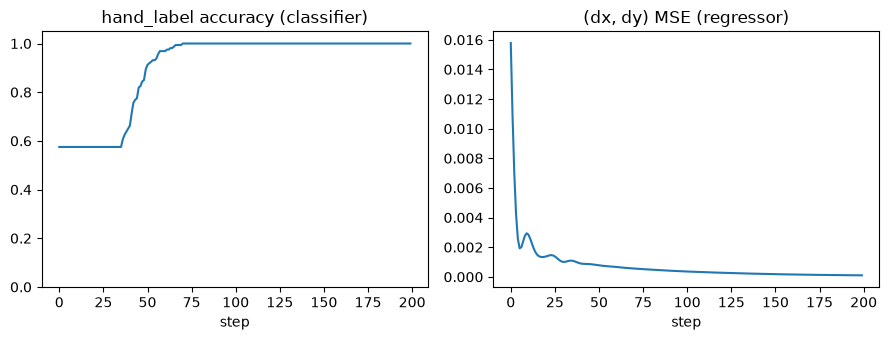

마지막 step: hand_acc=1.00, offset_mse=0.000101


In [8]:
decoder.classifier.train()
decoder.regressor.train()
classifier_opt = torch.optim.Adam(decoder.classifier.parameters(), lr=1e-3)
regressor_opt = torch.optim.Adam(decoder.regressor.parameters(), lr=1e-3)
ce_loss_fn = torch.nn.CrossEntropyLoss()
mse_loss_fn = torch.nn.MSELoss()

X_train_t = torch.from_numpy(X_train).float()
hand_train_t = torch.from_numpy(hand_train).long()
offset_train_t = torch.from_numpy(offset_train).float()

n_steps = 200
history = {"hand_acc": [], "offset_mse": []}
for step in range(n_steps):
    classifier_opt.zero_grad()
    class_logits = decoder.classifier(X_train_t)
    ce = ce_loss_fn(class_logits, hand_train_t)
    ce.backward()
    classifier_opt.step()

    regressor_opt.zero_grad()
    offset_pred = decoder.regressor(X_train_t)
    mse = mse_loss_fn(offset_pred, offset_train_t)
    mse.backward()
    regressor_opt.step()

    acc = (class_logits.argmax(dim=1) == hand_train_t).float().mean().item()
    history["hand_acc"].append(acc)
    history["offset_mse"].append(mse.item())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(history["hand_acc"])
axes[0].set_title("hand_label accuracy (classifier)")
axes[0].set_ylim(0, 1.05)
axes[1].plot(history["offset_mse"])
axes[1].set_title("(dx, dy) MSE (regressor)")
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()

print(
    f"마지막 step: hand_acc={history['hand_acc'][-1]:.2f}, "
    f"offset_mse={history['offset_mse'][-1]:.6f}"
)

## 7. `N2O` 파이프라인으로 검증 샘플 구동

In [ ]:
class ValidationSampleSignal:
    """검증 세트의 합성 신호를 순서대로 돌려주는 signal 소스."""

    def __init__(self, samples):
        self.samples = samples
        self.i = 0

    def read(self):
        sample = self.samples[self.i]
        self.i += 1
        return sample


N_VALID_SAMPLES = 3
samples = [X_valid[i] for i in range(N_VALID_SAMPLES)]
true_hand = [HAND_LABELS[hand_valid[i]] for i in range(N_VALID_SAMPLES)]
true_offset = [offset_valid[i] for i in range(N_VALID_SAMPLES)]

n2o = N2O()
n2o.signal = ValidationSampleSignal(samples)
n2o.decoder = decoder
n2o.command = command
n2o.robot.hand = AmazingHand()
# 3절에서 만든 Simulator를 재사용합니다 -- N2O.run(controller="simulation")은
# robot.simulator가 이미 설정돼 있으면 새로 만들거나 뷰어를 새로 띄우지 않으므로, 팔 쪽을
# apply_arm_offset()으로 직접 구동하면서 손 쪽만 n2o.run()에 맡기는 이 노트북의 조합에 맞습니다.
n2o.robot.simulator = simulator
# robot.arm은 일부러 비워둡니다 -- 아래 루프가 apply_arm_offset()으로 직접 구동하고,
# Robot.router()는 robot.arm이 None이면 "arm" 키를 그냥 건너뜁니다.

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

In [ ]:
for i in range(N_VALID_SAMPLES):
    predicted = decoder(samples[i])
    print(f"--- 검증 샘플 {i + 1}/{N_VALID_SAMPLES} ---")
    print(f"  실제: hand={true_hand[i]}, offset={true_offset[i].round(4)}")
    print(
        f"  예측: hand={HAND_LABELS[predicted['hand_class']]}, "
        f"dx={predicted['dx']:.4f}, dy={predicted['dy']:.4f}"
    )
    target_deg, ik_error = apply_arm_offset(predicted["dx"], predicted["dy"])
    print(f"  팔 IK 목표: {target_deg} (residual error={ik_error:.4f}m)")
    n2o.run(
        controller="simulation"
    )  # robot.arm이 None이라 router()는 손만 실제로 구동합니다

## 8. 가동범위 확인

IK로 풀어낸 관절 각도(`current_arm_deg`, 위 루프가 매 스텝 갱신한 최종 상태)가 실제로 공식
가동범위 안에 있었는지 확인합니다 — `SO101IKSolver.solve()`가 매 반복마다 이미 그 범위로
clamp하므로, 여기서는 그게 실제로 지켜졌는지 `ik_solver.model`의 `jnt_range`와 직접 대조해 다시
한번 확인하는 것입니다.

In [ ]:
print("관절별 가동범위 확인 (공식 벤더 값 기준):")
current_arm_rad = real_deg_to_mj_rad(current_arm_deg)
for joint in ARM_JOINTS:
    joint_id = mujoco.mj_name2id(ik_solver.model, mujoco.mjtObj.mjOBJ_JOINT, joint)
    lo, hi = ik_solver.model.jnt_range[joint_id]
    value = current_arm_rad[joint]
    status = "OK" if lo - 1e-6 <= value <= hi + 1e-6 else "범위 초과"
    print(
        f"  {joint:14s}: {value:6.3f} rad   (공식 범위 [{lo:6.3f}, {hi:6.3f}])   {status}"
    )

## 정리

- `MixedDecoder`는 trunk를 공유하지 않는 완전히 독립적인 두 모델(`HandGestureClassifier`,
  `ArmOffsetRegressor`)을 감싸고, 여전히 순수 예측만 합니다 — `N2O`의 디코더 슬롯이 하나뿐이라, 두
  방식을 섞으려면 이렇게 한 디코더가 두 모델을 함께 들고 있어야 했지만, 모델 자체는 각자 다른
  optimizer/loss로 독립적으로 학습됩니다. `config.type = (DecoderType.CLASSIFICATION,
  DecoderType.REGRESSION)`로 표시했습니다.
- `MixedCommand`는 분류 결과(`hand_class`)를 자기 설명적인 이름(`"grip"`/`"release"`)으로 바꾸고,
  회귀 결과(`dx`, `dy`)는 raw 값이므로 `(ActionType.CARTESIAN_RELATIVE, {...})` 튜플로 태그해서
  나눠 보냅니다.
- 손과 팔이 이번 노트북에서 서로 다른 경로로 구동됩니다 — 손은 `AmazingHand` + `Robot.router()`가
  `04`번과 동일하게 처리하지만(`n2o.run(controller="simulation")`이 매 사이클 `goal()` +
  `Simulator.drive("hand", ...)`를 호출), 팔은 `SO101Arm`이 아직 Cartesian 오프셋을 모르므로
  (`ROADMAP.md`) `Robot.router()`를 완전히 건너뛰고 `SO101IKSolver.solve()`를 직접 호출합니다 —
  현재 위치에 `(dx, dy)` 상대 이동량을 더한 목표점을 감쇠 최소제곱 IK로 관절 각도로 직접 풀어내며,
  매 반복마다 공식 가동범위로 clamp합니다. `solve()` 자신은 상태를 기억하지 않는 순수 함수라,
  "지금 팔이 어디 있는지"는 이 노트북이 `current_arm_deg` 변수로 직접 추적합니다.
- `04`(전부 분류) · `05`(전부 회귀, 절대 관절각) · `08`(혼합 + 상대 이동 + IK), 세 노트북 모두 같은
  `Decoder`/`Command`/`Part`(`goal()`/`move()`) + `Robot.router()` 구조를 공유합니다 — 다만 이
  노트북은 팔이 아직 지원하지 않는 액션 타입(Cartesian 상대 이동)을 다루기 때문에, 팔 쪽만
  `Robot.router()`를 우회해 `SO101IKSolver`를 직접 부른다는 점이 다른 두 노트북과 다릅니다.
- `AmazingHand()`는 이 노트북에서 실제로 인스턴스화되지만, `n2o.robot.controller`가
  `ControllerType.SIMULATION`로 고정돼 있어 `Robot.router()`는 `goal()`(순수 계산)만 부르고
  `move()`(실제 서보 구동)는 한 번도 호출되지 않습니다 — 물리적으로 연결된 실제 AmazingHand는
  전혀 건드리지 않았습니다. `SO101Arm`은 이 노트북에서 아예 인스턴스화되지 않았습니다(팔은
  `SO101IKSolver`의 순수 계산 결과를 `Simulator.drive("arm", ...)`로 직접 시각화할 뿐입니다).